In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

df = pd.read_csv("cleaned_stock_prices.csv")

SYMBOL = "AAPL"
stock = df[df["symbol"] == SYMBOL].copy()
stock["date"] = pd.to_datetime(stock["date"])
stock = stock.sort_values("date")

print("Duplicate dates:", stock["date"].duplicated().sum())
print("Rows:", len(stock))
print("Date range:", stock["date"].min(), "to", stock["date"].max())

stock = stock.set_index("date")
ts = stock["close"]

Duplicate dates: 0
Rows: 1007
Date range: 2014-01-02 00:00:00 to 2017-12-29 00:00:00


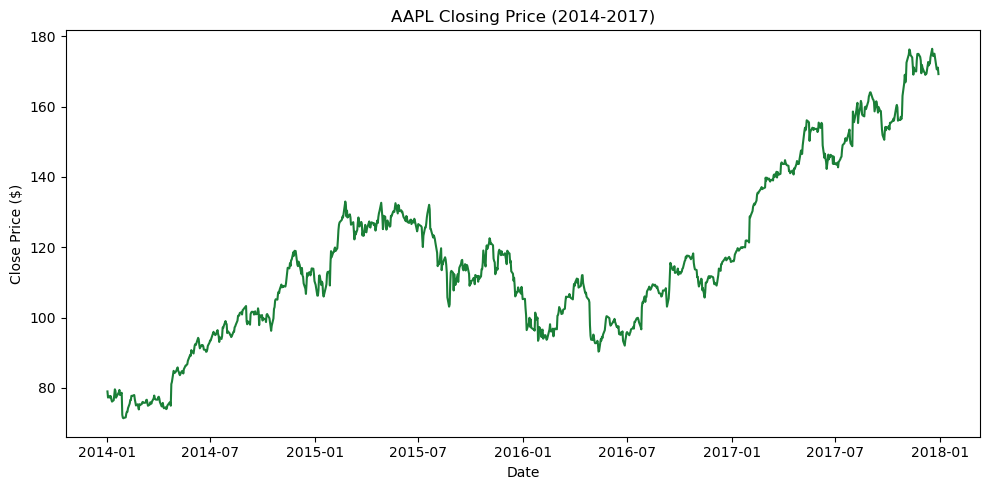

In [2]:
plt.figure(figsize=(10, 5))
plt.plot(ts, color="#1a7f37")
plt.title(f"{SYMBOL} Closing Price (2014-2017)")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.tight_layout()
plt.savefig("ts_raw.png", dpi=150)
plt.show()

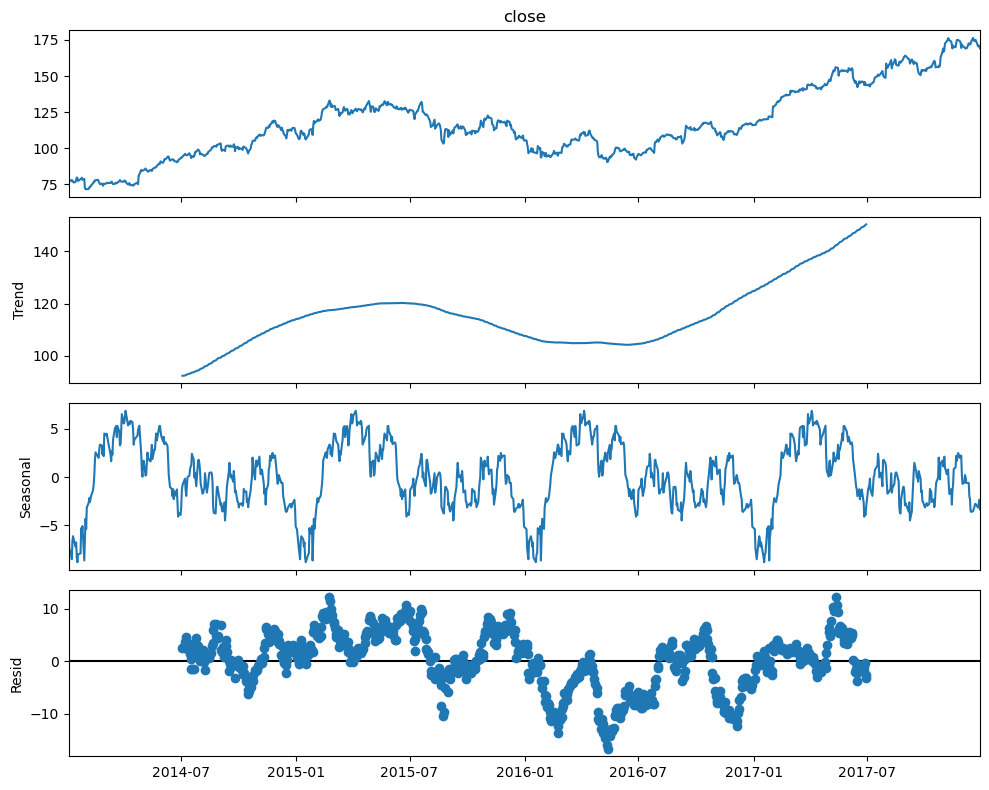

In [3]:
# period=252 treats one trading year (~252 trading days) as one seasonal cycle
result = seasonal_decompose(ts, model="additive", period=252)

fig = result.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.savefig("ts_decompose.png", dpi=150)
plt.show()

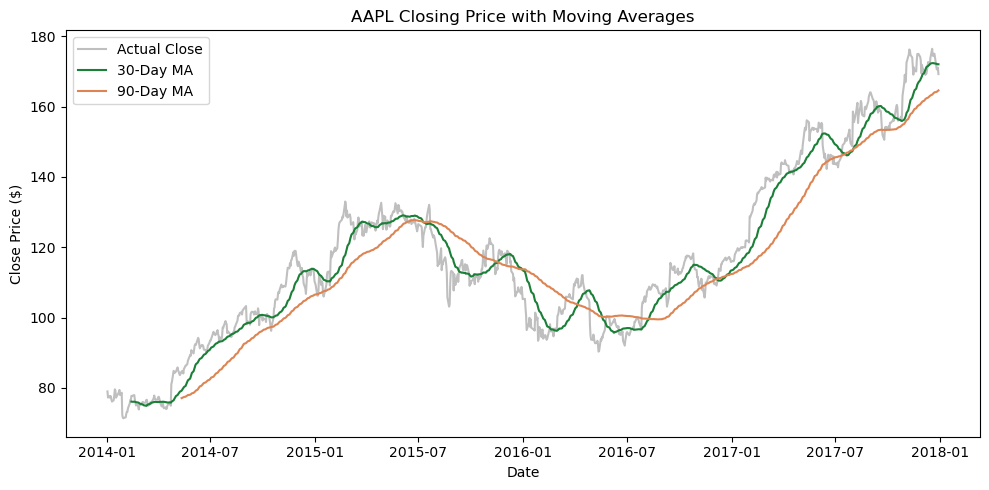

In [4]:
ma30 = ts.rolling(window=30).mean()
ma90 = ts.rolling(window=90).mean()

plt.figure(figsize=(10, 5))
plt.plot(ts, label="Actual Close", alpha=0.5, color="gray")
plt.plot(ma30, label="30-Day MA", color="#1a7f37")
plt.plot(ma90, label="90-Day MA", color="#DD8452")
plt.title(f"{SYMBOL} Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.legend()
plt.tight_layout()
plt.savefig("ts_ma.png", dpi=150)
plt.show()